In [16]:
#Checking which environment the python jupyter is using

In [17]:
import sys
print(sys.executable)

C:\Users\Dell\anaconda3\envs\vision_env\python.exe


In [18]:
#Installing pandas and numpy in the same environment Jupyter is using

In [19]:
import sys
!{sys.executable} -m pip install pandas numpy

In [20]:
#Importing libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
#Loading the dataset

In [7]:
df = pd.read_csv("clean_finance_data.csv")

**Exploratory Data Analysis (EDA)**

In [24]:
#Using shape to verify dataset size and ensuring data consistency
#Returns the rows and columns present in the data

In [25]:
df.shape

(1231, 7)

In [26]:
#Used tail() to quickly inspect the data structure and validate column values
#Returns the last five rows (by default) of the data

In [27]:
df.tail()

,Year,Month_Year,Date,Transaction_Type,Category,Amount,Remark
1226,2025,Mar-25,2025-03-14,Expense,Transport,-116.0,Rapids
1227,2025,Mar-25,2025-03-01,Expense,Transport,-530.0,Taxi
1228,2025,Aug-25,2025-08-15,Expense,Transport,-88.7,uber cancel fee
1229,2026,Jan-26,2026-01-04,Expense,Transport,-300.0,Cab
1230,2026,Jan-26,2026-01-24,Expense,Transport,-420.0,Cab to TMV


In [28]:
#Using info() to check the datatypes and identify missing values

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1231 entries, 0 to 1230
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              1231 non-null   int64  
 1   Month_Year        1231 non-null   object 
 2   Date              1231 non-null   object 
 3   Transaction_Type  1231 non-null   object 
 4   Category          1231 non-null   object 
 5   Amount            1231 non-null   float64
 6   Remark            1231 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 67.4+ KB


In [30]:
#Used describe() to understand data distribution and identify anomalies

In [31]:
df.describe()

,Year,Amount
count,1231.000000,1231.000000
mean,2025.177092,138.589066
std,0.381902,6201.172574
min,2025.000000,-21593.000000
25%,2025.000000,-380.000000
50%,2025.000000,-200.000000
75%,2025.000000,-60.000000
max,2026.000000,140916.180000


**Data Cleaning**

In [32]:
#Checking if there are any missing values present in the data
#Used isnull() to identify missing values before analysis

In [33]:
df.isnull().sum()

Year                0
Month_Year          0
Date                0
Transaction_Type    0
Category            0
Amount              0
Remark              0
dtype: int64

In [34]:
#Returns all the columns present in the data

In [35]:
df.columns

Index(['Year', 'Month_Year', 'Date', 'Transaction_Type', 'Category', 'Amount',
       'Remark'],
      dtype='object')

In [87]:
#Removing rows with missing Amount values to ensure accurate financial calculations
#Used dropna() to remove missing values

In [88]:
df= df.dropna (subset=['Amount'])

In [89]:
#Converted the Date column into proper datetime format to enable time-based analysis
#Used to_datetime() to fix the date format

In [90]:
df ['Date'] = pd.to_datetime(df['Date'])

**Feature Engineerring**

In [91]:
#Creating a new column to enable monthly aggregation and trend analysis

In [92]:
df['Month'] = df['Date'].dt.strftime('%Y-%m')

**Analysis**

In [93]:
#Total Income vs Expense

In [94]:
#Grouped data by transaction type to calculate total income and expense

In [96]:
df.groupby('Transaction_Type')['Amount'].sum().abs()

Transaction_Type
Expense    693174.03
Income     863777.17
Name: Amount, dtype: float64

In [97]:
#Category-wise Expense

In [98]:
#Filtering only the expense transaction type and grouping by category and adding the expenses in each category

In [99]:
#Analyzed category-wise expenses to identify major spending areas

In [100]:
df[df['Transaction_Type']=='Expense'].groupby ('Category')['Amount'].sum().abs()

Category
Dress              3624.00
Food              38893.35
Fuel              10475.00
Grocery          132744.27
Health            37494.56
Home             284131.14
Other Expense     27916.29
Other Income       6757.07
Others            95799.45
Snacks            16985.40
Tickets           19497.80
Transport         18855.70
Name: Amount, dtype: float64

In [101]:
#Spending Behaviour Pattern

In [102]:
#Counts how many times each category appears

In [103]:
#Using value_counts() to understand frequency distribution of categories

In [104]:
df['Category'].value_counts()

Category
Grocery          324
Snacks           150
Food             142
Home             141
Other Income     138
Others           116
Health            72
Fuel              55
Transport         49
Other Expense     26
Tickets           10
Dress              8
Name: count, dtype: int64

In [105]:
#Monthly Savings Trend 

In [106]:
#Net Savings = Income - Expense

In [107]:
#Grouping by month and adding the income and expense per month
#My Data Structure: Income + (-Expense) = Net Savings
#Analyzed monthly trends to understand financial performance over time

In [108]:
df.groupby ('Month')['Amount'].sum()

Month
2025-03    76477.03
2025-04    65915.21
2025-05     4941.66
2025-06     2332.47
2025-07     1675.43
2025-08     9338.40
2025-09      657.45
2025-10     1301.31
2025-11      261.38
2025-12     1764.03
2026-01     1963.12
2026-02     3975.65
Name: Amount, dtype: float64

In [109]:
#Visualization of Monthly Savings Trend

In [110]:
#Grouping the data by month and sums the amount 
#Used .plot() to convert the numbers into a graph
#Used plt.title() to add a title to the graph
#Used plt.show() to display the graph

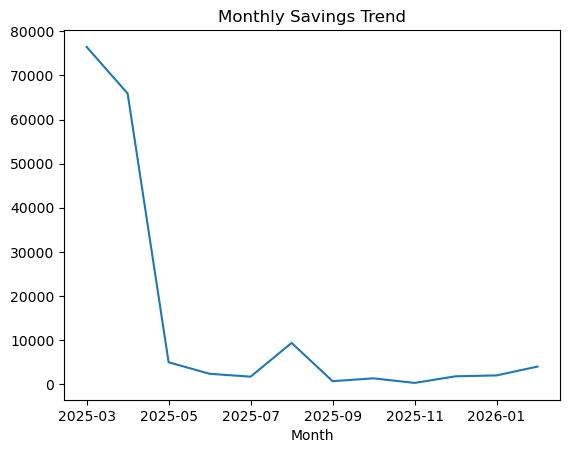

In [111]:
df.groupby('Month')['Amount'].sum().plot()
plt.title("Monthly Savings Trend")
plt.show()